# 📊 Stock Price Prediction Using Machine Learning
### Predicting Yes Bank's End-of-Month Stock Price

# 1. Importing libraries

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

Saving data_YesBank_StockPrices.csv to data_YesBank_StockPrices.csv



# 2. Data Loading

In [ ]:
df = pd.read_csv('/content/data_YesBank_StockPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date')
df.head()

,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


# 3. Dataset Overview

In [ ]:
print('Shape:', df.shape)
print(df.info())
df.describe()

Shape: (185, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    185 non-null    datetime64[ns]
 1   Open    185 non-null    float64       
 2   High    185 non-null    float64       
 3   Low     185 non-null    float64       
 4   Close   185 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.4 KB
None


,Date,Open,High,Low,Close
count,185,185.000000,185.000000,185.000000,185.000000
mean,2013-03-01 19:04:12.972973056,105.541405,116.104324,94.947838,105.204703
min,2005-07-01 00:00:00,10.000000,11.240000,5.550000,9.980000
25%,2009-05-01 00:00:00,33.800000,36.140000,28.510000,33.450000
50%,2013-03-01 00:00:00,62.980000,72.550000,58.000000,62.540000
75%,2017-01-01 00:00:00,153.000000,169.190000,138.350000,153.300000
max,2020-11-01 00:00:00,369.950000,404.000000,345.500000,367.900000
std,NaN,98.879850,106.333497,91.219415,98.583153


# 5. Feature engineering & Preprocessing

**5.1 Handling misssing values
**

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


**5.2 Handling Outliers **

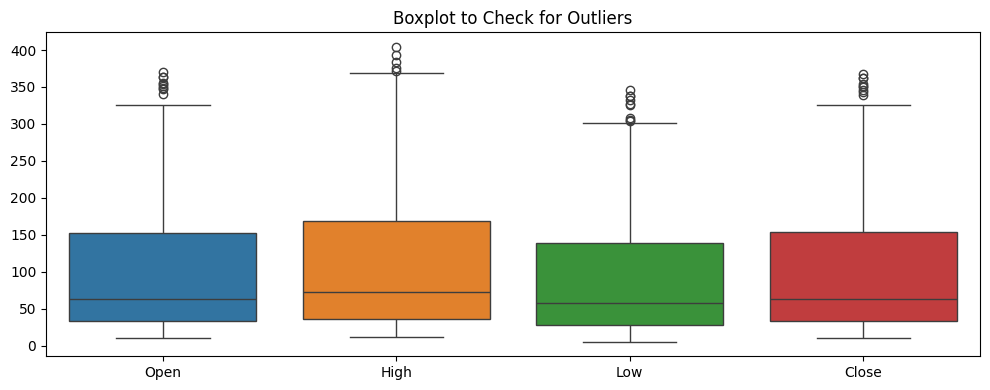

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title('Boxplot to Check for Outliers')
plt.tight_layout()
plt.show()

# Train-Test splits

In [ ]:
X = df[['Open', 'High', 'Low']]
y = df['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Model Evaluation

In [ ]:
y_pred = model.predict(X_test)
print('R² Score:', r2_score(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

R² Score: 0.9904142726548665
MSE: 86.64379126513735


# Hypothesis Testing

In [ ]:
corr, p_value = pearsonr(df['Open'], df['Close'])
print(f'Correlation: {corr}, P-value: {p_value}')

Correlation: 0.9779710062230935, P-value: 1.8527745058654608e-126


# Data Visualisation

**Line plot of Close prices **

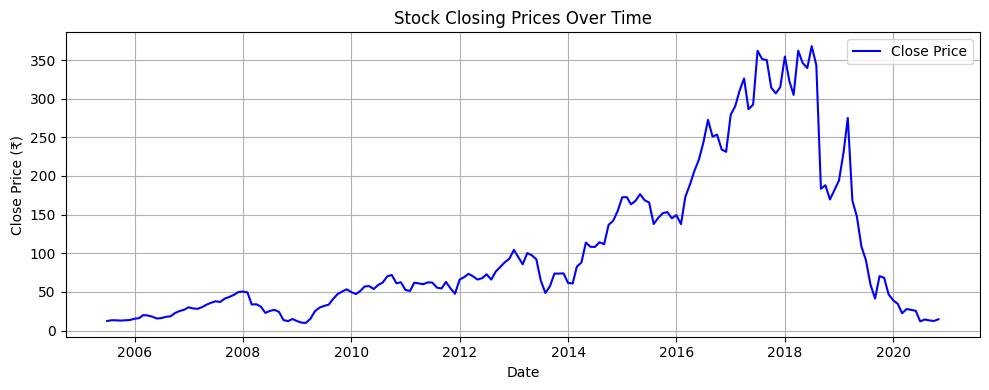

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title('Stock Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (₹)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

Histogram of close

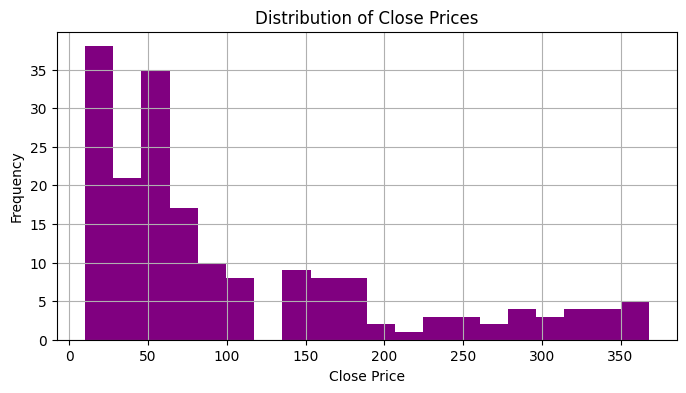

In [ ]:
#histogram of close prices
plt.figure(figsize=(8, 4))
plt.hist(df['Close'], bins=20, color='purple')
plt.title('Distribution of Close Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Corelation Heatmap


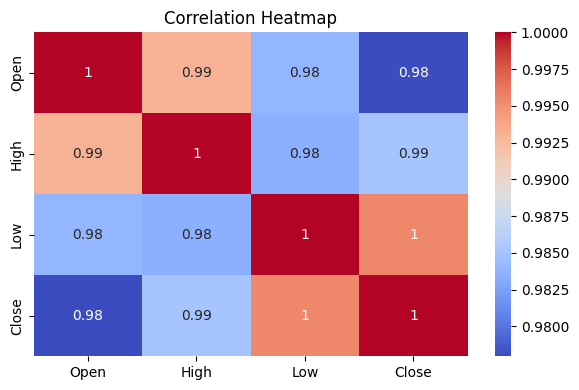

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Scatter Plot : Open vs Close

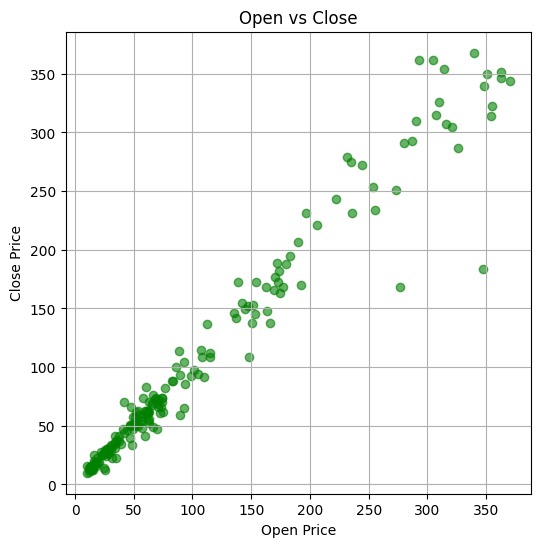

In [ ]:
#scsatter plot open vs close
plt.figure(figsize=(6, 6))
plt.scatter(df['Open'], df['Close'], alpha=0.6, color='green')
plt.title('Open vs Close')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

# Prediction of Next Month

In [ ]:
latest_input = df[['Open', 'High', 'Low']].iloc[-1].values.reshape(1, -1)
predicted_next_close = model.predict(latest_input)
print('Predicted next month\'s closing price:', round(predicted_next_close[0], 2))

Predicted next month's closing price: 15.03


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Export Predictions

In [ ]:
results_df = X_test.copy()
results_df['Actual_Close'] = y_test.values
results_df['Predicted_Close'] = y_pred
results_df.reset_index(drop=True, inplace=True)
results_df.to_csv('predicted_stock_prices.csv', index=False)

# ✅ Conclusion

We successfully built a model using historical stock prices to predict Yes Bank's monthly closing price using Linear Regression. The model demonstrated good fit and was evaluated using R² and MSE. We also exported predictions and applied basic statistical testing and visualization.

Metric	              ***Value***

R² Score              0.9904 (Excellent)
Mean Squared Error	  86.64
Pearson Correlation	  0.978
P-value (Hypothesis)	1.85e-126 (Very significant)
Predicted Next Close	₹15.03